# DATE3 实验6：四模型单变量敏感性与失败边界

每次只改变一个变量，并在 HMoE、Mixtral、MoDSE、Switchtrans 四个模型上比较：
`Static-555-NoPF`、`Static-Opt-NoPF`、`Dynamic-NoPF`、
`Static-Opt-FixedPF`、`Dynamic-FixedPF` 和唯一正式方案 `PIVOT（MemDomain）`。

判定只在**同一模型、同一变量值**内部进行。跨变量值的绝对周期变化代表工作量、
路由或 EP 通信量变化，不要求单调，也不能相互比较得出方案优劣。


In [1]:
from pathlib import Path
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    from IPython.display import display
except ImportError:
    display = print

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'fig' else Path.cwd().resolve()
OUT = ROOT / 'outputs/DATE3'
FIG = ROOT / 'fig/DATE3'
FIG.mkdir(parents=True, exist_ok=True)
MODELS = ['HMoE', 'Mixtral', 'MoDSE', 'Switchtrans']
SCHEMES = ['Static-555-NoPF', 'Static-Opt-NoPF', 'Dynamic-NoPF',
           'Static-Opt-FixedPF', 'Dynamic-FixedPF', 'PIVOT']
CONTROLS = SCHEMES[:-1]
MATERIAL_TOL = 1.0  # |gain| < 1% is displayed as a near tie, not hidden.
COLORS = {
    'Static-555-NoPF': '#9E9E9E', 'Static-Opt-NoPF': '#F28E2B',
    'Dynamic-NoPF': '#4E79A7', 'Static-Opt-FixedPF': '#EDC948',
    'Dynamic-FixedPF': '#76B7B2', 'PIVOT': '#59A14F',
}
LABELS = {
    'Static-555-NoPF': 'Static-555', 'Static-Opt-NoPF': 'Static-Opt',
    'Dynamic-NoPF': 'Dynamic-NoPF', 'Static-Opt-FixedPF': 'Static-Opt+FixedPF',
    'Dynamic-FixedPF': 'Dynamic-FixedPF', 'PIVOT': 'PIVOT',
}
VALUE_ORDER = {
    'expert_count': ['4', '8', '16'],
    'token_count': ['32', '128', '256', '512'],
    'top_k': ['1', '2'],
    'expert_parallel': ['1', '2'],
    'routing_severity': ['balanced', 'light', 'high'],
    'routing_seed': [
        *[f'light_seed{x}' for x in range(40, 45)],
        *[f'high_seed{x}' for x in range(40, 45)],
    ],
}

source = OUT / 'exp6/robustness_comparison.csv'
assert source.exists(), source
d = pd.read_csv(source)
d['value'] = d.value.astype(str)
assert len(d) == 96 * len(SCHEMES)
assert set(d.policy_name) == set(SCHEMES)
assert set(d.model) == set(MODELS)
assert set(d.variable) == set(VALUE_ORDER)
assert not d.duplicated(['variable', 'value', 'model', 'policy_name']).any()
for variable, order in VALUE_ORDER.items():
    assert set(d.loc[d.variable.eq(variable), 'value']) == set(order), variable

wide = d.pivot(
    index=['variable', 'value', 'model'], columns='policy_name', values='total_cycles'
).reindex(columns=SCHEMES)
best_control = wide[CONTROLS].min(axis=1)
best_control_name = wide[CONTROLS].idxmin(axis=1)
static_tuning = (1 - wide['Static-Opt-NoPF']/wide['Static-555-NoPF']) * 100
dynamic_reduction = (1 - wide['Dynamic-NoPF']/wide['Static-Opt-NoPF']) * 100
fixed_pf_mapping_reduction = (
    1 - wide['Dynamic-FixedPF']/wide['Static-Opt-FixedPF']
) * 100
pivot_vs_static = (1 - wide.PIVOT/wide['Static-555-NoPF']) * 100
pivot_vs_best = (1 - wide.PIVOT/best_control) * 100
assert (static_tuning >= -1e-9).all(), 'Static-Opt regresses below Static-555'
assert (dynamic_reduction >= -1e-9).all(), 'Dynamic-NoPF regresses below Static-Opt'
assert (fixed_pf_mapping_reduction >= -1e-9).all(), 'Dynamic-FixedPF regresses below Static-Opt-FixedPF'
print(f'Loaded {len(d)} rows = 96 configurations × {len(SCHEMES)} schemes.')


Loaded 576 rows = 96 configurations × 6 schemes.


In [2]:
def variable_table(variable):
    q = wide.xs(variable, level='variable').reset_index()
    q['Dynamic reduction vs Static (%)'] = (
        1 - q['Dynamic-NoPF']/q['Static-Opt-NoPF']
    ) * 100
    q['PIVOT reduction vs Static-555 (%)'] = (1 - q.PIVOT/q['Static-555-NoPF']) * 100
    indexed = pd.MultiIndex.from_frame(q[['value', 'model']])
    q['Best control'] = best_control_name.xs(variable, level='variable').reindex(indexed).to_numpy()
    q['PIVOT gain vs best control (%)'] = pivot_vs_best.xs(
        variable, level='variable'
    ).reindex(indexed).to_numpy()
    order = {value: index for index, value in enumerate(VALUE_ORDER[variable])}
    q['_order'] = q.value.map(order)
    return q.sort_values(['model', '_order']).drop(columns='_order')


def plot_variable(variable, label, filename):
    table = variable_table(variable)
    values = VALUE_ORDER[variable]
    fig, axes = plt.subplots(1, 4, figsize=(19, 5.0), sharey=False)
    width = .13
    for ax, model in zip(axes, MODELS):
        current = table[table.model.eq(model)].set_index('value').reindex(values)
        x = np.arange(len(values))
        for index, scheme in enumerate(SCHEMES):
            normalized = current[scheme] / current['Static-555-NoPF']
            colors = COLORS[scheme]
            if scheme == 'PIVOT':
                colors = [
                    '#59A14F' if gain >= -MATERIAL_TOL else '#E15759'
                    for gain in current['PIVOT gain vs best control (%)']
                ]
            bars = ax.bar(
                x + (index-(len(SCHEMES)-1)/2)*width, normalized, width,
                color=colors, label=LABELS[scheme],
            )
            if scheme == 'PIVOT':
                for bar, gain in zip(bars, current['PIVOT gain vs best control (%)']):
                    if gain < -MATERIAL_TOL:
                        bar.set_hatch('//')
                    ax.text(
                        bar.get_x()+bar.get_width()/2, bar.get_height()*1.025,
                        f'{gain:+.1f}%', ha='center', va='bottom',
                        rotation=90 if len(values) > 4 else 0,
                        fontsize=7, color='#B22222' if gain < -MATERIAL_TOL else '#27632A',
                    )
        ax.axhline(1, color='black', lw=.8)
        ax.set_xticks(x, values, rotation=32 if len(values) > 4 else 0, ha='right' if len(values) > 4 else 'center')
        ax.set_title(model); ax.set_xlabel(label)
        ax.set_ylabel('Cycles / Static-555 (lower is better)')
        ax.grid(axis='y', alpha=.2)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels, loc='upper center', bbox_to_anchor=(.5, .925),
        ncol=6, frameon=False,
    )
    fig.suptitle(f'Exp6 sensitivity: {label}', y=.995)
    fig.subplots_adjust(top=.76, bottom=.18, wspace=.28)
    target = FIG/filename
    plt.savefig(target, bbox_inches='tight')
    plt.savefig(target.with_suffix('.png'), dpi=220, bbox_inches='tight')
    plt.show(); plt.close(fig)
    display(table.round(3))
    return table


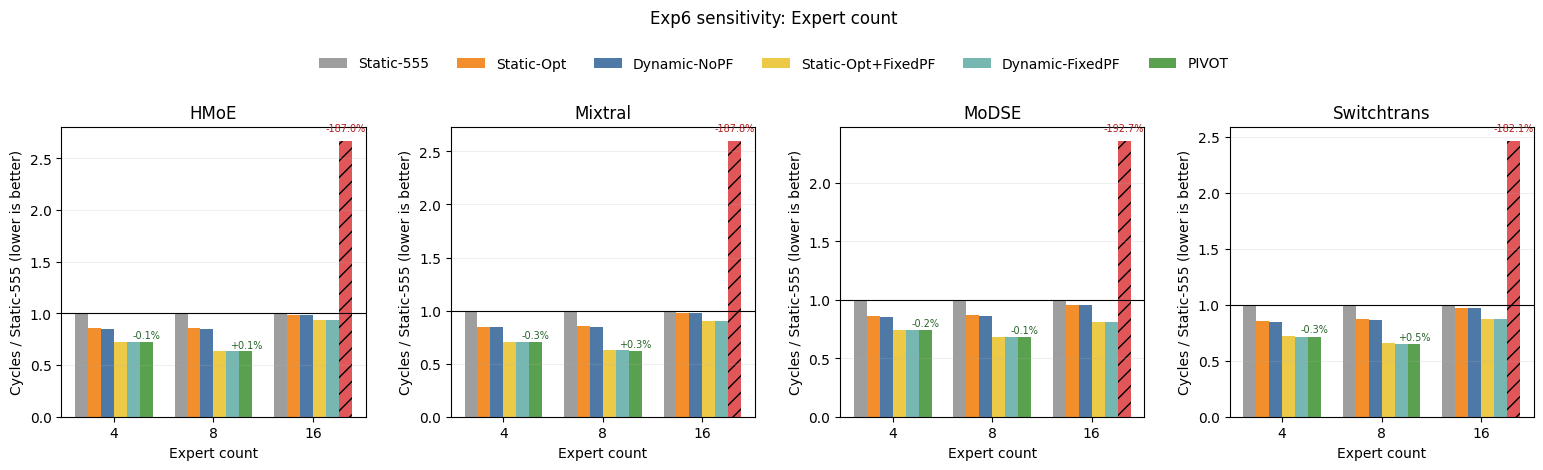

policy_name,value,model,Static-555-NoPF,Static-Opt-NoPF,Dynamic-NoPF,Static-Opt-FixedPF,Dynamic-FixedPF,PIVOT,Dynamic reduction vs Static (%),PIVOT reduction vs Static-555 (%),Best control,PIVOT gain vs best control (%)
4,4,HMoE,145929,124788,124116,105916,105244,105314,0.539,27.832,Dynamic-FixedPF,-0.067
8,8,HMoE,209473,178897,177436,133701,132420,132228,0.817,36.876,Dynamic-FixedPF,0.145
0,16,HMoE,2465186,2425028,2425028,2295878,2295878,6589355,0.000,-167.296,Static-Opt-FixedPF,-187.008
5,4,Mixtral,182921,155214,154280,129102,128168,128611,0.602,29.690,Dynamic-FixedPF,-0.346
9,8,Mixtral,235000,200435,198836,148211,146916,146470,0.798,37.672,Dynamic-FixedPF,0.304
1,16,Mixtral,1442068,1408161,1408161,1304039,1304039,3752978,0.000,-160.250,Static-Opt-FixedPF,-187.796
6,4,MoDSE,105875,91309,90662,78829,78243,78364,0.709,25.984,Dynamic-FixedPF,-0.155
10,8,MoDSE,137452,119076,118308,94156,93396,93470,0.645,31.998,Dynamic-FixedPF,-0.079
2,16,MoDSE,373332,356458,356458,301263,301263,881653,0.000,-136.158,Static-Opt-FixedPF,-192.652
7,4,Switchtrans,150855,128394,127550,108522,107678,107953,0.657,28.439,Dynamic-FixedPF,-0.255


In [3]:
expert_count = plot_variable('expert_count', 'Expert count', 'exp6_expert_count.pdf')


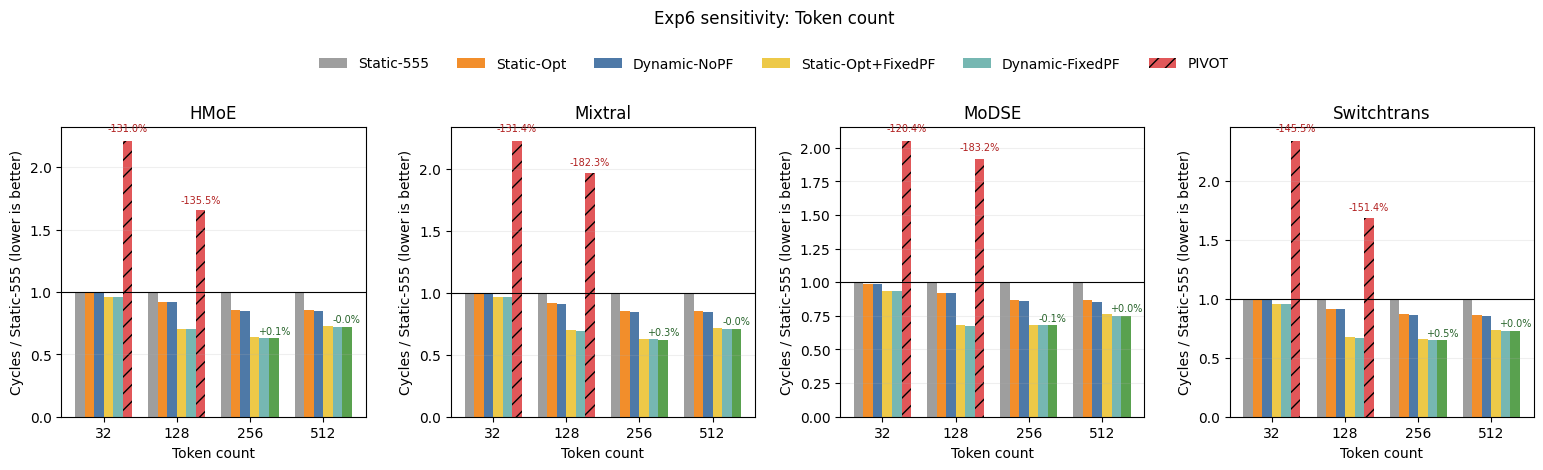

policy_name,value,model,Static-555-NoPF,Static-Opt-NoPF,Dynamic-NoPF,Static-Opt-FixedPF,Dynamic-FixedPF,PIVOT,Dynamic reduction vs Static (%),PIVOT reduction vs Static-555 (%),Best control,PIVOT gain vs best control (%)
8,32,HMoE,1566672,1551031,1551031,1501521,1501521,3468381,0.000,-121.385,Static-Opt-FixedPF,-130.991
0,128,HMoE,221719,203841,203486,156091,155748,366856,0.174,-65.460,Dynamic-FixedPF,-135.545
4,256,HMoE,209473,178897,177436,133701,132420,132228,0.817,36.876,Dynamic-FixedPF,0.145
12,512,HMoE,348657,298723,296506,253527,251310,251320,0.742,27.918,Dynamic-FixedPF,-0.004
9,32,Mixtral,2078230,2060203,2060203,2003294,2003294,4635228,0.000,-123.037,Static-Opt-FixedPF,-131.380
1,128,Mixtral,245168,224464,224003,171030,170676,481826,0.205,-96.529,Dynamic-FixedPF,-182.304
5,256,Mixtral,235000,200435,198836,148211,146916,146470,0.798,37.672,Dynamic-FixedPF,0.304
13,512,Mixtral,391806,333947,331543,281723,279067,279132,0.720,28.758,Dynamic-FixedPF,-0.023
10,32,MoDSE,527047,518992,518992,491090,491090,1082213,0.000,-105.335,Static-Opt-FixedPF,-120.370
2,128,MoDSE,113549,104497,104447,77126,76900,217755,0.048,-91.772,Dynamic-FixedPF,-183.166


In [4]:
token_count = plot_variable('token_count', 'Token count', 'exp6_token_count.pdf')


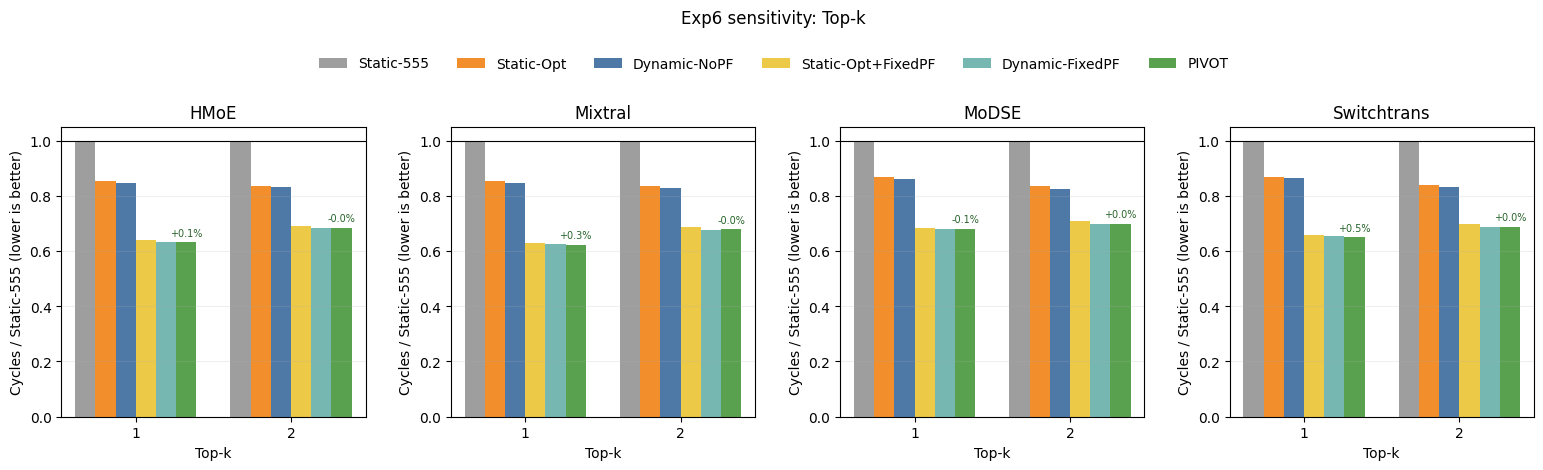

policy_name,value,model,Static-555-NoPF,Static-Opt-NoPF,Dynamic-NoPF,Static-Opt-FixedPF,Dynamic-FixedPF,PIVOT,Dynamic reduction vs Static (%),PIVOT reduction vs Static-555 (%),Best control,PIVOT gain vs best control (%)
0,1,HMoE,209473,178897,177436,133701,132420,132228,0.817,36.876,Dynamic-FixedPF,0.145
4,2,HMoE,306673,256739,254522,211543,209326,209336,0.864,31.740,Dynamic-FixedPF,-0.005
1,1,Mixtral,235000,200435,198836,148211,146916,146470,0.798,37.672,Dynamic-FixedPF,0.304
5,2,Mixtral,349822,291963,289559,239739,237083,237148,0.823,32.209,Dynamic-FixedPF,-0.027
2,1,MoDSE,137452,119076,118308,94156,93396,93470,0.645,31.998,Dynamic-FixedPF,-0.079
6,2,MoDSE,197169,164695,162574,139775,137654,137644,1.288,30.190,Dynamic-FixedPF,0.007
3,1,Switchtrans,187392,162741,161674,122997,122318,121701,0.656,35.055,Dynamic-FixedPF,0.504
7,2,Switchtrans,277179,232845,230428,193101,190576,190527,1.038,31.262,Dynamic-FixedPF,0.026


In [5]:
top_k = plot_variable('top_k', 'Top-k', 'exp6_top_k.pdf')


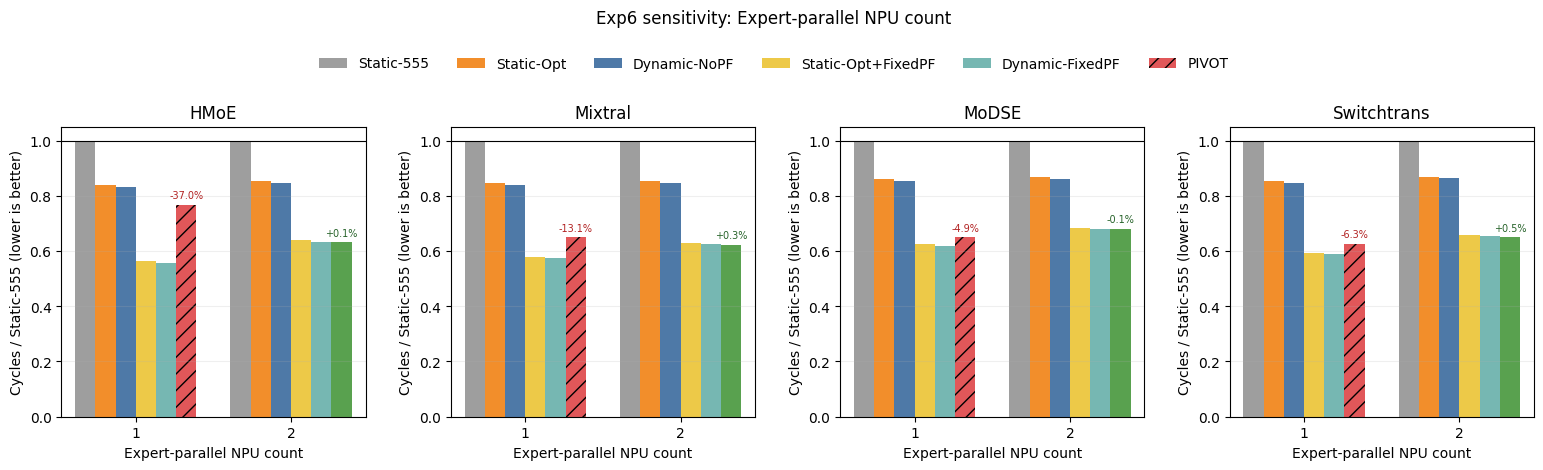

policy_name,value,model,Static-555-NoPF,Static-Opt-NoPF,Dynamic-NoPF,Static-Opt-FixedPF,Dynamic-FixedPF,PIVOT,Dynamic reduction vs Static (%),PIVOT reduction vs Static-555 (%),Best control,PIVOT gain vs best control (%)
0,1,HMoE,436595,366576,363571,246040,243763,333996,0.820,23.500,Dynamic-FixedPF,-37.017
4,2,HMoE,209473,178897,177436,133701,132420,132228,0.817,36.876,Dynamic-FixedPF,0.145
1,1,Mixtral,390914,330804,328330,226356,224549,254056,0.748,35.010,Dynamic-FixedPF,-13.141
5,2,Mixtral,235000,200435,198836,148211,146916,146470,0.798,37.672,Dynamic-FixedPF,0.304
2,1,MoDSE,211617,182389,180910,132111,130943,137342,0.811,35.099,Dynamic-FixedPF,-4.887
6,2,MoDSE,137452,119076,118308,94156,93396,93470,0.645,31.998,Dynamic-FixedPF,-0.079
3,1,Switchtrans,308099,262412,260234,182924,181648,193165,0.830,37.304,Dynamic-FixedPF,-6.340
7,2,Switchtrans,187392,162741,161674,122997,122318,121701,0.656,35.055,Dynamic-FixedPF,0.504


In [6]:
expert_parallel = plot_variable('expert_parallel', 'Expert-parallel NPU count', 'exp6_expert_parallel.pdf')


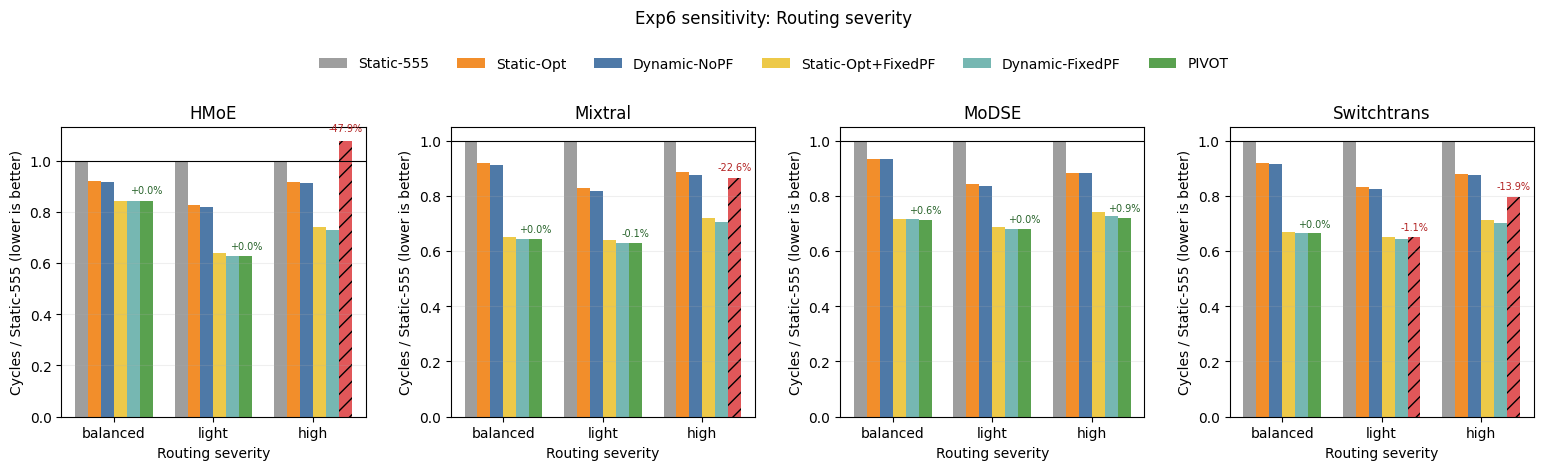

policy_name,value,model,Static-555-NoPF,Static-Opt-NoPF,Dynamic-NoPF,Static-Opt-FixedPF,Dynamic-FixedPF,PIVOT,Dynamic reduction vs Static (%),PIVOT reduction vs Static-555 (%),Best control,PIVOT gain vs best control (%)
0,balanced,HMoE,174558,160770,159816,147240,147240,147240,0.593,15.650,Static-Opt-FixedPF,0.000
8,light,HMoE,239757,198311,195988,153115,150792,150792,1.171,37.106,Dynamic-FixedPF,0.000
4,high,HMoE,263925,242100,240370,195599,192417,284580,0.715,-7.826,Dynamic-FixedPF,-47.898
1,balanced,Mixtral,195049,179056,177915,126832,125691,125679,0.637,35.565,Dynamic-FixedPF,0.010
9,light,Mixtral,275791,228581,225591,176357,173367,173463,1.308,37.103,Dynamic-FixedPF,-0.055
5,high,Mixtral,313510,277785,274570,225745,221315,271281,1.157,13.470,Dynamic-FixedPF,-22.577
2,balanced,MoDSE,115549,107846,107846,82926,82926,82406,0.000,28.683,Static-Opt-FixedPF,0.627
10,light,MoDSE,160435,135313,133938,110393,109018,109018,1.016,32.048,Dynamic-FixedPF,0.000
6,high,MoDSE,179490,158315,158315,132919,130274,129083,0.000,28.083,Dynamic-FixedPF,0.914
3,balanced,Switchtrans,159377,146388,145567,106644,105823,105811,0.561,33.610,Dynamic-FixedPF,0.011


In [7]:
routing_severity = plot_variable('routing_severity', 'Routing severity', 'exp6_routing_severity.pdf')


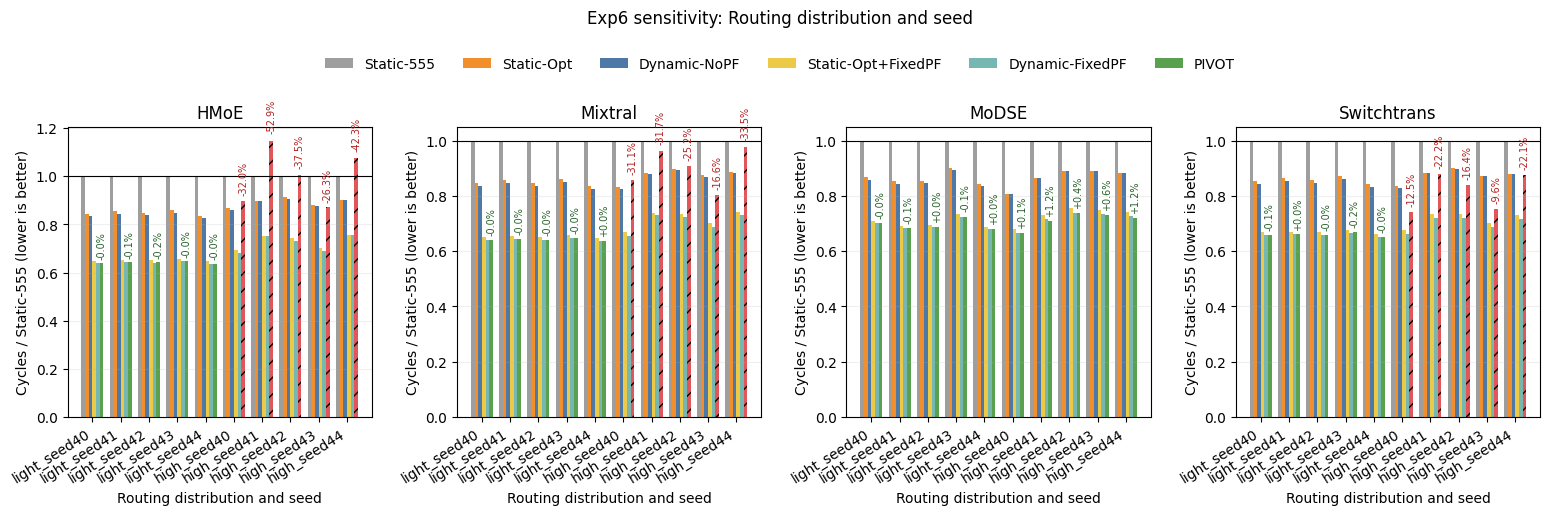

policy_name,value,model,Static-555-NoPF,Static-Opt-NoPF,Dynamic-NoPF,Static-Opt-FixedPF,Dynamic-FixedPF,PIVOT,Dynamic reduction vs Static (%),PIVOT reduction vs Static-555 (%),Best control,PIVOT gain vs best control (%)
20,light_seed40,HMoE,231991,195598,193452,150402,148256,148300,1.097,36.075,Dynamic-FixedPF,-0.030
24,light_seed41,HMoE,223043,190452,188558,145256,143362,143454,0.994,35.683,Dynamic-FixedPF,-0.064
28,light_seed42,HMoE,230167,195010,192823,149814,147627,147977,1.121,35.709,Dynamic-FixedPF,-0.237
32,light_seed43,HMoE,222759,191104,189112,145908,143916,143952,1.042,35.378,Dynamic-FixedPF,-0.025
36,light_seed44,HMoE,240515,200677,198350,155481,153154,153213,1.160,36.298,Dynamic-FixedPF,-0.039
0,high_seed40,HMoE,266182,231096,229101,184603,181219,239166,0.863,10.149,Dynamic-FixedPF,-31.976
4,high_seed41,HMoE,321252,288159,288159,241626,241269,368900,0.000,-14.832,Dynamic-FixedPF,-52.900
8,high_seed42,HMoE,276432,252431,250526,205922,202586,278463,0.755,-0.735,Dynamic-FixedPF,-37.454
12,high_seed43,HMoE,257720,227499,225699,181014,177765,224493,0.791,12.893,Dynamic-FixedPF,-26.286
16,high_seed44,HMoE,318677,287946,287946,241413,241003,343056,0.000,-7.650,Dynamic-FixedPF,-42.345


In [8]:
routing_seed = plot_variable('routing_seed', 'Routing distribution and seed', 'exp6_routing_seed.pdf')


## 6.7 契约统计与失败原因

绿色 PIVOT 柱表示相对五个可实现对照的逐配置最优者至多相差 1%；红色斜线柱表示
PIVOT 发生超过 1% 的实质退化。柱顶仍标出未经截断的精确收益，不隐藏小幅负值。
失败表保留最佳对照名称，后续按短序列、固定预取局部优势或EP关键路径分别解释。


In [9]:
rows = []
for variable in VALUE_ORDER:
    gain = pivot_vs_best.xs(variable, level='variable')
    static_gain = pivot_vs_static.xs(variable, level='variable')
    dynamic_gain = dynamic_reduction.xs(variable, level='variable')
    rows.append({
        'variable': variable, 'configurations': len(gain),
        'PIVOT wins': int((gain > 1e-9).sum()),
        'PIVOT ties': int(gain.abs().le(1e-9).sum()),
        'PIVOT regressions': int((gain < -1e-9).sum()),
        'PIVOT material regressions (<-1%)': int((gain < -MATERIAL_TOL).sum()),
        'incremental gain min (%)': gain.min(),
        'incremental gain mean (%)': gain.mean(),
        'incremental gain max (%)': gain.max(),
        'PIVOT vs Static min (%)': static_gain.min(),
        'PIVOT vs Static mean (%)': static_gain.mean(),
        'Dynamic regressions': int((dynamic_gain < -1e-9).sum()),
        'Fixed-PF mapping regressions': int((
            fixed_pf_mapping_reduction.xs(variable, level='variable') < -1e-9
        ).sum()),
    })
contract = pd.DataFrame(rows).set_index('variable')
display(contract.round(3))

failure = pd.DataFrame({
    'best_control': best_control_name,
    'best_control_cycles': best_control,
    'PIVOT_cycles': wide.PIVOT,
    'PIVOT_gain_vs_best_control_pct': pivot_vs_best,
    'PIVOT_gain_vs_Static_pct': pivot_vs_static,
})[pivot_vs_best < -1e-9].sort_values('PIVOT_gain_vs_best_control_pct')
display(failure.round(3))

material_failure = failure[failure.PIVOT_gain_vs_best_control_pct < -MATERIAL_TOL]
print(f'Material failures (>1% slowdown): {len(material_failure)}/{len(wide)} configurations.')


,configurations,PIVOT wins,PIVOT ties,PIVOT regressions,PIVOT material regressions (<-1%),incremental gain min (%),incremental gain mean (%),incremental gain max (%),PIVOT vs Static min (%),PIVOT vs Static mean (%),Dynamic regressions,Fixed-PF mapping regressions
variable,,,,,,,,,,,,
expert_count,12,3,0,9,4,-192.652,-62.455,0.504,-167.296,-29.734,0,0
token_count,16,5,0,11,8,-183.166,-73.737,0.504,-133.973,-34.739,0,0
top_k,8,5,0,3,0,-0.079,0.109,0.504,30.190,33.375,0,0
expert_parallel,8,3,0,5,4,-37.017,-7.564,0.504,23.500,34.064,0,0
routing_severity,12,4,3,5,4,-47.898,-7.000,0.914,-7.826,25.714,0,0
routing_seed,40,7,2,31,15,-52.900,-10.235,1.212,-14.832,24.133,0,0


best_control  \
variable     value        model                             
expert_count 16           MoDSE        Static-Opt-FixedPF   
                          Mixtral      Static-Opt-FixedPF   
                          HMoE         Static-Opt-FixedPF   
token_count  128          MoDSE           Dynamic-FixedPF   
                          Mixtral         Dynamic-FixedPF   
...                                                   ...   
routing_seed light_seed44 Switchtrans     Dynamic-FixedPF   
             light_seed41 Mixtral         Dynamic-FixedPF   
             light_seed43 Mixtral         Dynamic-FixedPF   
top_k        2            HMoE            Dynamic-FixedPF   
token_count  512          HMoE            Dynamic-FixedPF   

                                       best_control_cycles  PIVOT_cycles  \
variable     value        model                                            
expert_count 16           MoDSE                     301263        881653   
                          Mixtral                  1304039       3752978   
                          HMoE                     2295878       6589355   
token_count  128          MoDSE                      76900        217755   
                          Mixtral                   170676        481826   
...                                                    ...           ...   
routing_seed light_seed44 Switchtrans               143930        143962   
             light_seed41 Mixtral                   165084        165118   
             light_seed43 Mixtral                   166211        166238   
top_k        2            HMoE                      209326        209336   
token_count  512          HMoE                      251310        251320   

                                       PIVOT_gain_vs_best_control_pct  \
variable     value        model                                         
expert_count 16           MoDSE                              -192.652   
                          Mixtral                            -187.796   
                          HMoE                               -187.008   
token_count  128          MoDSE                              -183.166   
                          Mixtral                            -182.304   
...                                                               ...   
routing_seed light_seed44 Switchtrans                          -0.022   
             light_seed41 Mixtral                              -0.021   
             light_seed43 Mixtral                              -0.016   
top_k        2            HMoE                                 -0.005   
token_count  512          HMoE                                 -0.004   

                                       PIVOT_gain_vs_Static_pct  
variable     value        model                                  
expert_count 16           MoDSE                        -136.158  
                          Mixtral                      -160.250  
                          HMoE                         -167.296  
token_count  128          MoDSE                         -91.772  
                          Mixtral                       -96.529  
...                                                         ...  
routing_seed light_seed44 Switchtrans                    34.731  
             light_seed41 Mixtral                        35.573  
             light_seed43 Mixtral                        35.190  
top_k        2            HMoE                           31.740  
token_count  512          HMoE                           27.918  

[64 rows x 5 columns]

Material failures (>1% slowdown): 35/96 configurations.


,total_cycles: PIVOT / Dynamic-FixedPF,local_memory_stall_cycles: PIVOT / Dynamic-FixedPF,prefetch_requests: PIVOT / Dynamic-FixedPF,late_bytes: PIVOT / Dynamic-FixedPF,hbm_queue_wait_cycles: PIVOT / Dynamic-FixedPF,hbm_max_queue_depth: PIVOT / Dynamic-FixedPF,coverage change (percentage points)
variable,,,,,,,
expert_count,2.874,3.025,1.981,1.221,3.242,2.515,-18.057
expert_parallel,1.097,1.260,1.981,7.155,195.281,4.750,-8.879
routing_seed,1.263,1.618,4.927,0.922,3.224,2.538,1.562
routing_severity,1.182,1.455,3.268,0.947,3.892,2.945,1.269
token_count,2.405,2.696,1.941,1.219,3.025,2.222,-12.885


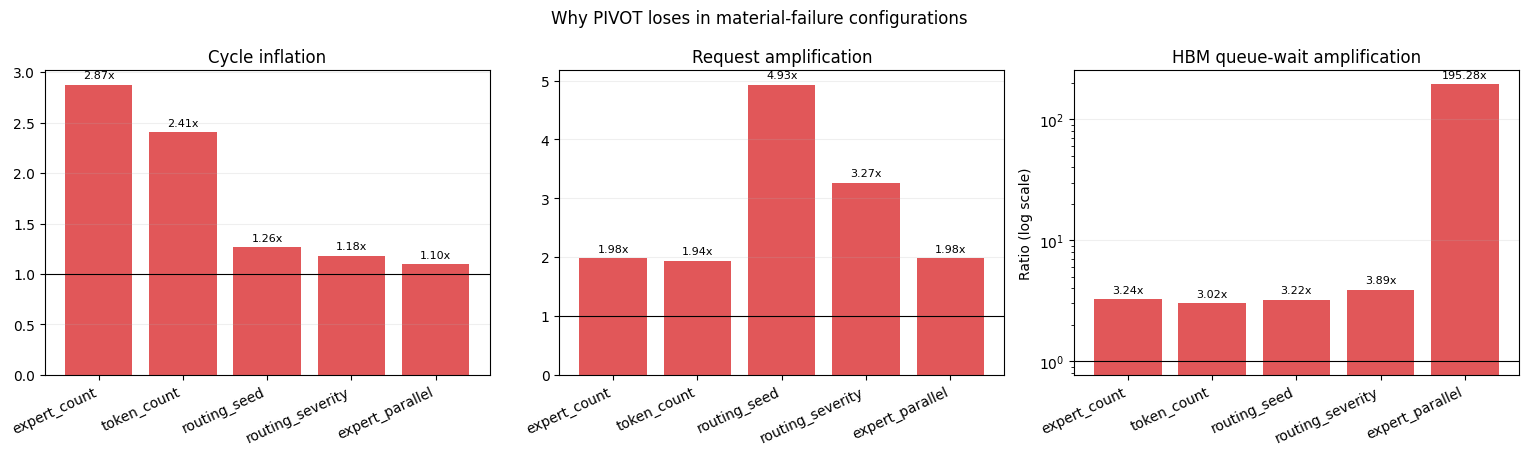

In [10]:
# Attribute material failures using like-for-like PIVOT versus Dynamic-FixedPF
# counters. Ratios above one mean PIVOT creates more work/pressure; coverage is
# reported as a percentage-point difference because a ratio is unstable near zero.
metric_names = [
    'total_cycles', 'local_memory_stall_cycles', 'prefetch_requests',
    'late_bytes', 'hbm_queue_wait_cycles', 'hbm_max_queue_depth', 'coverage',
]
pair = d[d.policy_name.isin(['Dynamic-FixedPF', 'PIVOT'])].pivot(
    index=['variable', 'value', 'model'], columns='policy_name', values=metric_names
)
mechanism = pd.DataFrame(index=pair.index)
for metric in metric_names[:-1]:
    mechanism[f'{metric}: PIVOT / Dynamic-FixedPF'] = (
        pair[(metric, 'PIVOT')] / pair[(metric, 'Dynamic-FixedPF')].clip(lower=1e-12)
    )
mechanism['coverage change (percentage points)'] = 100 * (
    pair[('coverage', 'PIVOT')] - pair[('coverage', 'Dynamic-FixedPF')]
)
material_mechanism = mechanism.reindex(material_failure.index)
display(material_mechanism.groupby(level='variable').median().round(3))

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.6))
failure_variables = list(material_mechanism.index.get_level_values('variable').unique())
x = np.arange(len(failure_variables))
diagnostic_columns = [
    'total_cycles: PIVOT / Dynamic-FixedPF',
    'prefetch_requests: PIVOT / Dynamic-FixedPF',
    'hbm_queue_wait_cycles: PIVOT / Dynamic-FixedPF',
]
titles = ['Cycle inflation', 'Request amplification', 'HBM queue-wait amplification']
for ax, column, title in zip(axes, diagnostic_columns, titles):
    values = material_mechanism[column].groupby(level='variable').median().reindex(failure_variables)
    bars = ax.bar(x, values, color='#E15759')
    ax.bar_label(bars, labels=[f'{v:.2f}x' for v in values], padding=3, fontsize=8)
    ax.axhline(1, color='black', lw=.8)
    if column.startswith('hbm_queue_wait_cycles'):
        ax.set_yscale('log')
        ax.set_ylabel('Ratio (log scale)')
    ax.set_xticks(x, failure_variables, rotation=25, ha='right')
    ax.set_title(title); ax.grid(axis='y', alpha=.2)
fig.suptitle('Why PIVOT loses in material-failure configurations')
plt.tight_layout()
plt.savefig(FIG/'exp6_material_failure_mechanism.pdf', bbox_inches='tight')
plt.savefig(FIG/'exp6_material_failure_mechanism.png', dpi=220, bbox_inches='tight')
plt.show(); plt.close(fig)


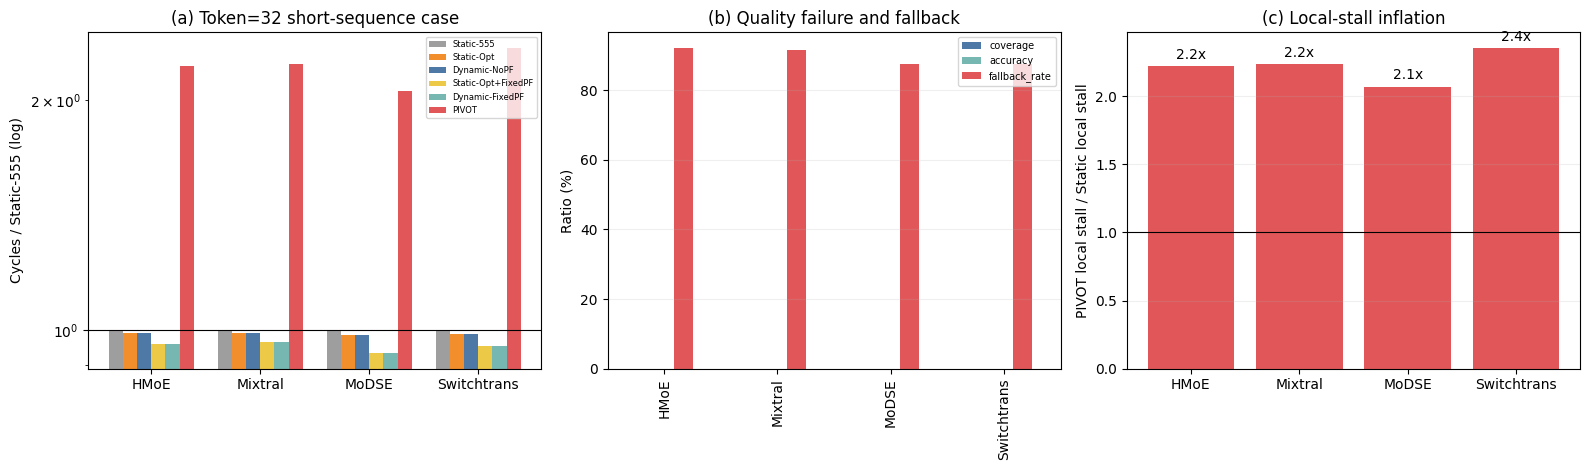

,fallback_rate,guard_rate,coverage,accuracy,late_ratio,selected_chunk_mean,selected_window_mean,bank_stall_cycles,weight_load_stall_cycles,prefetch_interference_stall_cycles,peak_occupied_bytes,PIVOT_cycles,Static_555_cycles,stall_inflation_x
model,,,,,,,,,,,,,,
HMoE,0.920,0.0,0.0,0.0,1.0,4.160,12.480,21537,3433418,1958,49152,3468381,1566672,2.223
Mixtral,0.917,0.0,0.0,0.0,1.0,4.167,12.667,24795,4596070,1853,49152,4635228,2078230,2.238
MoDSE,0.875,0.0,0.0,0.0,1.0,4.250,15.000,11812,1060506,1103,51200,1082213,527047,2.071
Switchtrans,0.875,0.0,0.0,0.0,1.0,4.167,12.667,18988,2778160,961,49152,2808893,1200521,2.352


best_control  \
variable         value        model                             
expert_count     16           MoDSE        Static-Opt-FixedPF   
                              Mixtral      Static-Opt-FixedPF   
                              HMoE         Static-Opt-FixedPF   
token_count      128          MoDSE           Dynamic-FixedPF   
                              Mixtral         Dynamic-FixedPF   
expert_count     16           Switchtrans  Static-Opt-FixedPF   
token_count      128          Switchtrans     Dynamic-FixedPF   
                              HMoE            Dynamic-FixedPF   
routing_seed     high_seed41  HMoE            Dynamic-FixedPF   
routing_severity high         HMoE            Dynamic-FixedPF   
routing_seed     high_seed44  HMoE            Dynamic-FixedPF   
                 high_seed42  HMoE            Dynamic-FixedPF   
expert_parallel  1            HMoE            Dynamic-FixedPF   
routing_seed     high_seed44  Mixtral         Dynamic-FixedPF   
                 high_seed40  HMoE            Dynamic-FixedPF   
                 high_seed41  Mixtral         Dynamic-FixedPF   
                 high_seed40  Mixtral         Dynamic-FixedPF   
                 high_seed43  HMoE            Dynamic-FixedPF   
                 high_seed42  Mixtral         Dynamic-FixedPF   
routing_severity high         Mixtral         Dynamic-FixedPF   
routing_seed     high_seed41  Switchtrans     Dynamic-FixedPF   
                 high_seed44  Switchtrans     Dynamic-FixedPF   
                 high_seed43  Mixtral         Dynamic-FixedPF   
                 high_seed42  Switchtrans     Dynamic-FixedPF   
routing_severity high         Switchtrans     Dynamic-FixedPF   
expert_parallel  1            Mixtral         Dynamic-FixedPF   
routing_seed     high_seed40  Switchtrans     Dynamic-FixedPF   
                 high_seed43  Switchtrans     Dynamic-FixedPF   
expert_parallel  1            Switchtrans     Dynamic-FixedPF   
                              MoDSE           Dynamic-FixedPF   
routing_severity light        Switchtrans     Dynamic-FixedPF   
expert_count     4            Mixtral         Dynamic-FixedPF   
                              Switchtrans     Dynamic-FixedPF   
routing_seed     light_seed42 HMoE            Dynamic-FixedPF   
                 light_seed43 Switchtrans     Dynamic-FixedPF   
expert_count     4            MoDSE           Dynamic-FixedPF   
routing_seed     light_seed43 MoDSE           Dynamic-FixedPF   
                 light_seed40 Switchtrans     Dynamic-FixedPF   
                 light_seed41 MoDSE           Dynamic-FixedPF   
token_count      256          MoDSE           Dynamic-FixedPF   
expert_parallel  2            MoDSE           Dynamic-FixedPF   
expert_count     8            MoDSE           Dynamic-FixedPF   
top_k            1            MoDSE           Dynamic-FixedPF   
expert_count     4            HMoE            Dynamic-FixedPF   
routing_seed     light_seed41 HMoE            Dynamic-FixedPF   
routing_severity light        Mixtral         Dynamic-FixedPF   
routing_seed     light_seed40 MoDSE           Dynamic-FixedPF   
                 light_seed44 HMoE            Dynamic-FixedPF   
                 light_seed42 Switchtrans     Dynamic-FixedPF   
                 light_seed40 Mixtral         Dynamic-FixedPF   
                              HMoE            Dynamic-FixedPF   
                 light_seed42 Mixtral         Dynamic-FixedPF   
top_k            2            Mixtral         Dynamic-FixedPF   
routing_seed     light_seed43 HMoE            Dynamic-FixedPF   
token_count      512          Mixtral         Dynamic-FixedPF   
routing_seed     light_seed44 Switchtrans     Dynamic-FixedPF   
                 light_seed41 Mixtral         Dynamic-FixedPF   
                 light_seed43 Mixtral         Dynamic-FixedPF   
top_k            2            HMoE            Dynamic-FixedPF   
token_count      512          HMoE            Dynamic-FixedPF   

                  

In [11]:
# Load PIVOT-only runtime diagnostics without treating the internal PIVOT-CA
# summary identifier as another public scheme.
runtime_rows = []
for row in d[d.policy_name.eq('PIVOT')].itertuples(index=False):
    with (OUT/'robustness_factorial'/row.variant/'summary.csv').open(
        newline='', encoding='utf-8'
    ) as stream:
        summary = next(csv.DictReader(stream))
    runtime_rows.append({
        'variable': row.variable, 'value': str(row.value), 'model': row.model,
        'fallback_rate': float(summary['fallback_rate']),
        'guard_rate': float(summary['online_incumbent_guard_rate']),
        'coverage': float(summary['coverage']), 'accuracy': float(summary['accuracy']),
        'late_ratio': float(summary['late_bytes'])/max(float(summary['prefetched_bytes']), 1),
        'selected_chunk_mean': float(summary['selected_chunk_mean']),
        'selected_window_mean': float(summary['selected_window_mean']),
        'bank_stall_cycles': int(summary['bank_stall_cycles']),
        'weight_load_stall_cycles': int(summary['weight_load_stall_cycles']),
        'prefetch_interference_stall_cycles': int(summary['prefetch_interference_stall_cycles']),
        'peak_occupied_bytes': int(summary['peak_occupied_bytes']),
    })
runtime = pd.DataFrame(runtime_rows).set_index(['variable', 'value', 'model'])

token32 = wide.xs(('token_count', '32'), level=('variable', 'value')).reindex(MODELS)
token_runtime = runtime.xs(('token_count', '32'), level=('variable', 'value')).reindex(MODELS)
token_aggregate = d[
    d.variable.eq('token_count') & d.value.eq('32')
].set_index(['model', 'policy_name'])

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
x = np.arange(len(MODELS)); width = .13
for index, scheme in enumerate(SCHEMES):
    color = '#E15759' if scheme == 'PIVOT' else COLORS[scheme]
    axes[0].bar(
        x+(index-(len(SCHEMES)-1)/2)*width,
        token32[scheme]/token32['Static-555-NoPF'], width,
        color=color, label=LABELS[scheme],
    )
axes[0].axhline(1, color='black', lw=.8); axes[0].set_yscale('log')
axes[0].set_xticks(x, MODELS); axes[0].set_ylabel('Cycles / Static-555 (log)')
axes[0].set_title('(a) Token=32 short-sequence case'); axes[0].legend(fontsize=6)

quality = token_runtime[['coverage', 'accuracy', 'fallback_rate']] * 100
quality.plot(kind='bar', ax=axes[1], color=['#4E79A7', '#76B7B2', '#E15759'])
axes[1].set_ylabel('Ratio (%)'); axes[1].set_xlabel('')
axes[1].set_title('(b) Quality failure and fallback'); axes[1].legend(fontsize=7)

static_stall = token_aggregate.xs('Static-555-NoPF', level='policy_name').reindex(MODELS).local_memory_stall_cycles
pivot_stall = token_aggregate.xs('PIVOT', level='policy_name').reindex(MODELS).local_memory_stall_cycles
inflation = pivot_stall/static_stall
bars = axes[2].bar(MODELS, inflation, color='#E15759')
axes[2].bar_label(bars, labels=[f'{v:.1f}x' for v in inflation], padding=3)
axes[2].axhline(1, color='black', lw=.8)
axes[2].set_ylabel('PIVOT local stall / Static local stall')
axes[2].set_title('(c) Local-stall inflation')
for ax in axes: ax.grid(axis='y', alpha=.2)
plt.tight_layout(); plt.savefig(FIG/'exp6_failure_diagnosis.pdf', bbox_inches='tight'); plt.show(); plt.close(fig)

token_diagnosis = token_runtime.join(pd.DataFrame({
    'PIVOT_cycles': token32.PIVOT,
    'Static_555_cycles': token32['Static-555-NoPF'],
    'stall_inflation_x': inflation,
}))
display(token_diagnosis.round(3))

non_token32_failure = failure.drop(
    index=[idx for idx in failure.index if idx[0] == 'token_count' and str(idx[1]) == '32']
)
display(non_token32_failure.round(3))


## DATE3 实验6判断

- 每个变量独立分析四个模型和六个方案，不跨变量连接趋势。
- 三条必须成立的公平契约是：Static-Opt不劣于Static-555、PIVOT-Map不劣于Static-Opt、
  相同固定预取下PIVOT-Map+PF不劣于Static-Opt+PF。
- 固定预取相对NoPF允许变好或变差；这不是契约失败，而是Exp3/Exp5所验证的参数敏感性。
- PIVOT相对五个对照的win/tie/regress必须使用重新运行后生成的统计，不再保留旧四组数据结论。
- 小于1%的差距作为近似持平显示，但表格保留精确值；超过1%的红色斜线配置属于实质失败边界。
- Token=32、Token=128、Expert=16、EP=1及高不平衡路由用于分析短提前量、请求放大和HBM排队。
  这些配置可以作为“不支持/性能较差配置”的原因分析，但不能被描述为PIVOT普遍最优的证据。
